# Finding the linear correlated-matching coefficients by black-box optimization

The `linear_cm` policy is **linear in 4 global coefficients** `theta = (c_joint, c_self, c_nbr, bias)`:

$$\delta w_\mu = \sum_{\nu} s_\nu\,(c_{\text{joint}}\,w_{\mu\nu} + c_{\text{self}}\,w_\mu + c_{\text{nbr}}\,w_\nu + \text{bias})$$

but the objective — the **logical error rate (LER)** after a second-pass MWPM — is *discontinuous,
non-convex, non-differentiable* (MWPM is a discrete argmin). No closed form, and PPO/REINFORCE are
overkill for a **4-D global** search. We treat it as a small black-box optimisation and compare:

1. **Nelder–Mead** (SciPy) — derivative-free simplex.
2. **CMA-ES** (`cma`) — evolution strategy (the parameter-space approach of Sivak et al. 2406.02700).
3. **Bayesian optimisation** (`scikit-optimize` `gp_minimize`) — GP surrogate + expected improvement.

Each evaluation is one **batched two-pass decode** with `edge_reweights` (first pass cached).
Reference points: plain **MWPM** and **analytical CM** `(1,-1,-1,0)`. All LERs are reported with
**binomial error bars**, and the final comparison uses a batch large enough for **>= 500 logical
errors** per decoder.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pymatching

from NeuralCM.syndrome_data_generation import SyndromeDataGenerator
from NeuralCM.drifted_matching_env import DriftedMatchingEnv
from NeuralCM.linear_correlated_matching import LinearCorrelatedMatching

# ---- problem setup (mismatch = 1, no drift) ----
DISTANCE = 5
N_ROUNDS = 5
P = 5e-3
BYPASS = 2
HOPS = 1

N_OPT = 15000        # shots for the optimisation objective (noisier, but cheap per eval)
TARGET_ERRORS = 500  # the final test batch is sized so every decoder gets at least this many errors
SEARCH_BOX = (-2.0, 2.0)   # per-coefficient bounds for CMA-ES / BO (good region is ~[-1.5, 1.5])
print(f"d={DISTANCE}, p={P}, N_opt={N_OPT}, target_errors={TARGET_ERRORS}")
print("NOTE: a full run is a few minutes; lower N_OPT or the per-method budgets to speed it up.")

In [ ]:
class ParametricCM:
    """
    Two-pass correlated matching whose 2nd-pass reweighting is the linear-CM rule
    parameterised by theta=(c_joint, c_self, c_nbr, bias). evaluate(theta) -> batch LER.
    The first pass (MWPM) is cached, so each call only redoes the second pass.
    """
    def __init__(self, p, n_shots, seed, distance=DISTANCE, n_rounds=N_ROUNDS,
                 bypass_threshold=BYPASS, hops=HOPS, mismatch=1.0):
        gen = SyndromeDataGenerator(
            distance=distance, n_rounds=n_rounds, mismatch=mismatch,
            noise_model={'version': 'built-in',
                         'after_clifford_depolarization': p,
                         'before_measure_flip_probability': p,
                         'after_reset_flip_probability': p,
                         'before_round_data_depolarization': p,
                         'p_gate_zz': 0.0},
            memory_type='z', n_shots=n_shots, qec_code='surface_code')
        self.env = DriftedMatchingEnv(
            syndrome_data_generator=gen, local_action_only=True, local_action_hops=hops,
            action_scale=1.0, update_period=n_shots + 1, n_test_shots=0,
            use_pearson_correlation=False, use_log_joint_prob=True,
            start_from_oracle=True, train_mode=True)
        env = self.env
        env.reset(seed=seed)

        self.shots = env.syndrome_batch
        self.true = env.true_obs_batch
        self.n = len(self.shots)
        self.fault = env.fault_array
        self.matching = pymatching.Matching.from_check_matrix(env.H, weights=env.current_weights)
        # linear_cm reweighting lives in src (src.LinearCorrelatedMatching); share THIS
        # env's edge ordering and just swap the 4 coefficients per evaluate(). The first
        # pass (cached below) is independent of theta, so only the 2nd pass is redone.
        self.ncm = LinearCorrelatedMatching.from_env(env, action_scale=1.0)

        ef = np.asarray(self.matching.decode_batch(self.shots, enable_correlations=False), dtype=bool)
        self.first_obs = (ef.astype(np.int64) @ self.fault) % 2
        self.nb = np.flatnonzero(self.shots.astype(np.int64).sum(1) > bypass_threshold)
        self.sel = [ef[s] for s in self.nb]
        self.mask = [env._compute_action_mask(np.flatnonzero(ef[s])) for s in self.nb]
        self.mwpm_errs = int(np.sum(self.first_obs != self.true))

    def errors(self, theta):
        """Number of logical errors for this theta (over all shots)."""
        self.ncm.set_coefficients(*theta)
        res = self.first_obs.copy()
        base_w = self.env.current_weights
        for k, s in enumerate(self.nb):
            new_w = self.ncm.new_weights(self.sel[k], self.mask[k])
            if np.array_equal(new_w, base_w):
                continue
            edges = self.matching.decode(self.shots[s], enable_correlations=False,
                                         edge_reweights=self.env._build_edge_reweights(new_w))
            res[s] = (np.asarray(edges, dtype=np.int64) @ self.fault) % 2
        return int(np.sum(res != self.true))

    def evaluate(self, theta):
        """LER for this theta."""
        return self.errors(theta) / self.n


def ler_se(ler, n):
    """Binomial standard error of an LER estimate."""
    return float(np.sqrt(ler * (1.0 - ler) / n)) if (n > 0 and 0 < ler < 1) else 0.0


pcm = ParametricCM(P, N_OPT, seed=123)        # optimisation objective
t = time.time(); _ = pcm.evaluate([1.0, -1.0, -1.0, 0.0])
print(f"objective ready | non-bypass shots: {len(pcm.nb)} | ~{time.time()-t:.2f}s per eval")

In [3]:
# Build the INDEPENDENT test batch large enough for >= TARGET_ERRORS for every decoder.
# Size it from the *best* (lowest-LER) reference we have so far (analytical CM on the opt batch).
CM_ANALYTIC = np.array([1.0, -1.0, -1.0, 0.0])
ZERO = np.array([0.0, 0.0, 0.0, 0.0])

cm_ler_opt = pcm.evaluate(CM_ANALYTIC)
n_test = int(np.ceil(TARGET_ERRORS / max(cm_ler_opt, 1e-4) * 1.3))   # 1.3x safety margin
n_test = int(np.clip(n_test, 30_000, 200_000))
print(f"Sizing test batch for >= {TARGET_ERRORS} errors at LER~{cm_ler_opt:.2e}  ->  N_test = {n_test:,}")
pcm_test = ParametricCM(P, n_test, seed=777)
print(f"test batch ready ({pcm_test.n:,} shots, {len(pcm_test.nb):,} non-bypass)")

Sizing test batch for >= 500 errors at LER~9.73e-03  ->  N_test = 66,781
test batch ready (66,781 shots, 62,185 non-bypass)


In [4]:
class Objective:
    """Wraps pcm.evaluate, recording every (theta, LER) so we can plot convergence."""
    def __init__(self, fn):
        self.fn = fn
        self.history = []      # (theta, ler)
    def __call__(self, theta):
        theta = np.asarray(theta, dtype=float)
        ler = self.fn(theta)
        self.history.append((theta, ler))
        return ler
    def best(self):
        i = int(np.argmin([l for _, l in self.history]))
        return self.history[i]
    def best_so_far(self):
        out, b = [], np.inf
        for _, l in self.history:
            b = min(b, l); out.append(b)
        return np.array(out)


# Baselines with binomial error bars on both batches.
def report(name, theta):
    lo = pcm.evaluate(theta);      so = ler_se(lo, pcm.n)
    et = pcm_test.errors(theta);   lt = et / pcm_test.n;  st = ler_se(lt, pcm_test.n)
    print(f"{name:26s} | opt {lo:.3e} +/- {so:.1e} | test {lt:.3e} +/- {st:.1e}  ({et} errors)")
    return lo, lt, st, et

print(f"{'baseline':26s} | {'LER(opt)':>16s} | {'LER(test) +/- SE':>22s}")
print('-' * 78)
report('MWPM (no reweight)', ZERO)
report('Analytical CM (1,-1,-1,0)', CM_ANALYTIC)

baseline                   |         LER(opt) |       LER(test) +/- SE
------------------------------------------------------------------------------
MWPM (no reweight)         | opt 1.440e-02 +/- 9.7e-04 | test 1.339e-02 +/- 4.4e-04  (894 errors)
Analytical CM (1,-1,-1,0)  | opt 9.733e-03 +/- 8.0e-04 | test 9.419e-03 +/- 3.7e-04  (629 errors)


(0.009733333333333333, 0.00941884667794732, 0.0003737811837930864, 629)

## Method 1 — Nelder–Mead (SciPy)

Derivative-free simplex. **Important:** with `x0=0` SciPy's default initial simplex uses a tiny
0.00025 step and stalls immediately, so we pass an explicit `initial_simplex` with a real scale.

In [5]:
from scipy.optimize import minimize

x0 = np.zeros(4)
step = 0.8
init_simplex = np.vstack([x0] + [x0 + step * np.eye(4)[i] for i in range(4)])

obj_nm = Objective(pcm.evaluate)
t = time.time()
res_nm = minimize(obj_nm, x0, method='Nelder-Mead',
                  options={'maxiter': 250, 'initial_simplex': init_simplex,
                           'xatol': 1e-2, 'fatol': 1e-5})
theta_nm, ler_nm = obj_nm.best()
print(f"Nelder-Mead: {len(obj_nm.history)} evals in {time.time()-t:.1f}s")
print(f"  theta = {np.round(theta_nm, 3)}  | LER(opt) = {ler_nm:.3e} +/- {ler_se(ler_nm, pcm.n):.1e}")

Nelder-Mead: 81 evals in 79.1s
  theta = [ 0.749 -0.786 -0.803 -0.209]  | LER(opt) = 9.333e-03 +/- 7.9e-04


## Method 2 — CMA-ES (`cma`)

Evolution strategy: sample a population from `N(mean, sigma^2 C)`, keep the best, adapt
`mean`/`sigma`/`C`. Robust to the noisy finite-shot objective — the parameter-space search of
Sivak et al. (arXiv:2406.02700).

In [6]:
import cma

obj_cma = Objective(pcm.evaluate)
t = time.time()
es = cma.CMAEvolutionStrategy(
    np.zeros(4), 0.5,
    {'bounds': [[SEARCH_BOX[0]] * 4, [SEARCH_BOX[1]] * 4],
     'maxfevals': 400, 'seed': 1, 'verbose': -9})
es.optimize(obj_cma)
theta_cma, ler_cma = obj_cma.best()
print(f"CMA-ES: {len(obj_cma.history)} evals in {time.time()-t:.1f}s")
print(f"  theta = {np.round(theta_cma, 3)}  | LER(opt) = {ler_cma:.3e} +/- {ler_se(ler_cma, pcm.n):.1e}")

CMA-ES: 408 evals in 524.3s
  theta = [ 0.79  -0.908 -0.866  0.196]  | LER(opt) = 9.267e-03 +/- 7.8e-04


## Method 3 — Bayesian optimisation (`scikit-optimize`)

GP surrogate + expected improvement — most sample-efficient. We keep the box tight (`[-2, 2]`,
the good region) and use plenty of random initial points so the noisy objective doesn't drive it
to the corners.

In [7]:
from skopt import gp_minimize

obj_bo = Objective(pcm.evaluate)
t = time.time()
res_bo = gp_minimize(lambda x: obj_bo(x),
                     dimensions=[SEARCH_BOX] * 4,
                     n_calls=120, n_initial_points=30,
                     acq_func='EI', noise=1e-6, random_state=0)
theta_bo, ler_bo = obj_bo.best()
print(f"Bayesian opt: {len(obj_bo.history)} evals in {time.time()-t:.1f}s")
print(f"  theta = {np.round(theta_bo, 3)}  | LER(opt) = {ler_bo:.3e} +/- {ler_se(ler_bo, pcm.n):.1e}")

Bayesian opt: 120 evals in 233.5s
  theta = [ 0.552 -0.69  -0.808  0.808]  | LER(opt) = 9.867e-03 +/- 8.1e-04


## Comparison

Each optimiser's best `theta` is re-scored on the **independent test batch** (sized for
>= 500 errors), and we report **LER +/- binomial SE**. `LER(opt)` and `LER(test)` differ because
they are two independent finite-shot samples (different seeds) and `LER(opt)` is the *in-sample*
value the optimiser tuned on — **judge the winner by `LER(test)` and its error bar.**

In [8]:
methods = {'Nelder-Mead': theta_nm, 'CMA-ES': theta_cma, 'Bayesian opt': theta_bo}

rows = []
for name, th in [('MWPM (no reweight)', ZERO), ('Analytical CM', CM_ANALYTIC), *methods.items()]:
    lo = pcm.evaluate(th)
    et = pcm_test.errors(th); lt = et / pcm_test.n; st = ler_se(lt, pcm_test.n)
    rows.append((name, np.asarray(th, float), lo, lt, st, et))

print(f"{'method':18s} {'c_joint':>8s} {'c_self':>8s} {'c_nbr':>8s} {'bias':>8s} "
      f"{'LER(opt)':>10s} {'LER(test)':>11s} {'+/-SE':>9s} {'errs':>6s}")
print('-' * 100)
for name, th, lo, lt, st, et in rows:
    print(f"{name:18s} {th[0]:8.3f} {th[1]:8.3f} {th[2]:8.3f} {th[3]:8.3f} "
          f"{lo:10.3e} {lt:11.3e} {st:9.1e} {et:6d}")

method              c_joint   c_self    c_nbr     bias   LER(opt)   LER(test)     +/-SE   errs
----------------------------------------------------------------------------------------------------
MWPM (no reweight)    0.000    0.000    0.000    0.000  1.440e-02   1.339e-02   4.4e-04    894
Analytical CM         1.000   -1.000   -1.000    0.000  9.733e-03   9.419e-03   3.7e-04    629
Nelder-Mead           0.749   -0.786   -0.803   -0.209  9.333e-03   9.000e-03   3.7e-04    601
CMA-ES                0.790   -0.908   -0.866    0.196  9.267e-03   9.015e-03   3.7e-04    602
Bayesian opt          0.552   -0.690   -0.808    0.808  9.867e-03   9.269e-03   3.7e-04    619


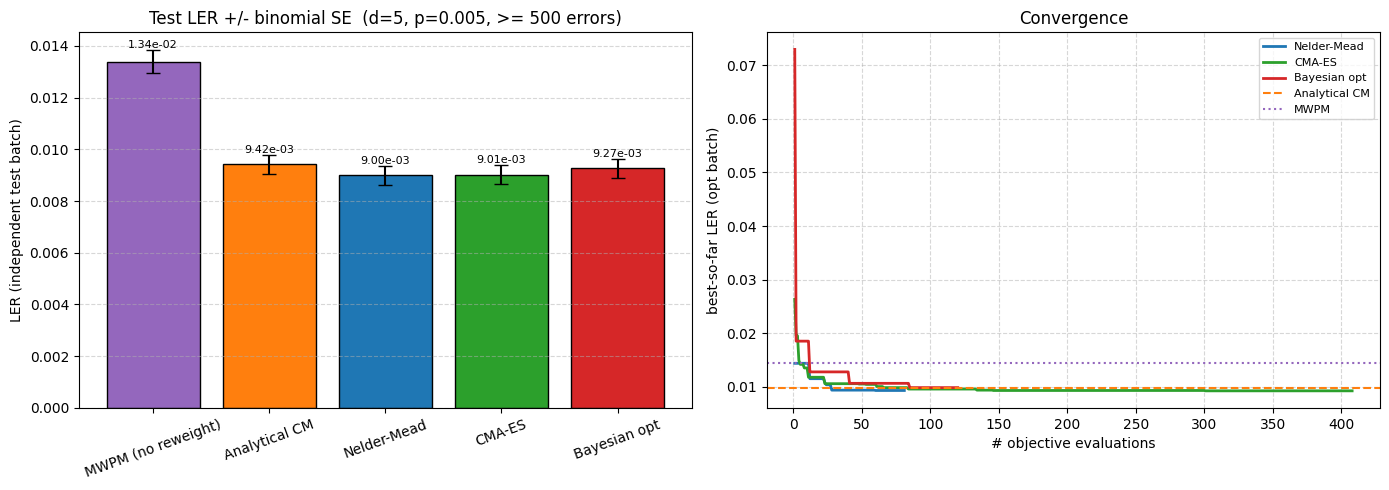

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- test LER with binomial error bars ---
names = [r[0] for r in rows]
test_lers = [r[3] for r in rows]
test_ses = [r[4] for r in rows]
colors = ['#9467bd', '#ff7f0e', '#1f77b4', '#2ca02c', '#d62728']
bars = ax1.bar(names, test_lers, yerr=test_ses, capsize=5,
               color=colors[:len(names)], edgecolor='black')
for b, v, s in zip(bars, test_lers, test_ses):
    ax1.text(b.get_x() + b.get_width()/2, v + s, f'{v:.2e}', ha='center', va='bottom', fontsize=8)
ax1.set_ylabel('LER (independent test batch)')
ax1.set_title(f'Test LER +/- binomial SE  (d={DISTANCE}, p={P}, >= {TARGET_ERRORS} errors)')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- convergence: best-so-far LER vs #evaluations ---
for label, obj, c in [('Nelder-Mead', obj_nm, '#1f77b4'),
                      ('CMA-ES', obj_cma, '#2ca02c'),
                      ('Bayesian opt', obj_bo, '#d62728')]:
    ax2.plot(np.arange(1, len(obj.history) + 1), obj.best_so_far(), label=label, color=c, linewidth=2)
ax2.axhline(pcm.evaluate(CM_ANALYTIC), color='#ff7f0e', linestyle='--', label='Analytical CM')
ax2.axhline(pcm.mwpm_errs / pcm.n, color='#9467bd', linestyle=':', label='MWPM')
ax2.set_xlabel('# objective evaluations')
ax2.set_ylabel('best-so-far LER (opt batch)')
ax2.set_title('Convergence')
ax2.legend(fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

## Takeaways

- All three methods optimise the **4 global coefficients directly against LER** via batched
  two-pass decodes — no critic/replay/PPO machinery and no sigma collapse/runaway to babysit.
- **`LER(opt)` vs `LER(test)`**: two independent finite-shot estimates on different seeds; the
  gap is statistical (overlapping error bars) and `LER(opt)` is mildly optimistic because the
  optimiser tuned on it. The >= 500-error **test** LER with its SE is the number to trust.
- The recovered `theta` typically lands near a **damped / conservative CM** (magnitudes < 1, a
  nonzero bias) — the reward-optimum at low `p`, matching the policy-gradient finding.
- **Efficiency:** Bayesian opt needs the fewest evaluations; CMA-ES is most robust to objective
  noise; Nelder-Mead is simplest but most noise-sensitive (give it the explicit initial simplex,
  and increase `N_OPT` if it still stalls).

To sharpen further: raise `N_OPT` (less objective noise) and/or the per-method budgets
(`maxiter`, `maxfevals`, `n_calls`); lower `P` only with a correspondingly larger `N_OPT`.

## Drift training (mismatch = 30, p = 4e-3) then LER vs p

Now optimise the coefficients in the **drift** setting used to train the RL agent: each
realization draws a different drifted circuit (`mismatch=30`, `p=4e-3`), seeded at the
**drifted-oracle** weights with **no alignment reweighting** (`start_from_oracle=True`,
`ParametricCM` defaults). The objective is the **pooled LER over several drift realizations**
(so the coefficients are drift-robust, not tuned to one drift).

The trained coefficients are then evaluated on **clean (mismatch = 1)** circuits across
`p = 2e-4 .. 1e-2` — the standard "train under drift, report clean LER-vs-p" protocol.

In [10]:
# ===== Train all three methods in the DRIFT setting (mismatch=30, p=4e-3) =====
from scipy.optimize import minimize
import cma
from skopt import gp_minimize

P_TRAIN        = 4e-3
MISMATCH_TRAIN = 30.0
N_DRIFTS       = 3          # pool the objective over this many drift realizations
N_TRAIN_PER    = 8000       # shots per drift realization
# per-method budgets (raise for precision; this is the main runtime knob)
NM_MAXITER, CMA_MAXFEVALS, BO_NCALLS = 150, 250, 80

print("NOTE: this trains 3 optimizers on a pooled multi-drift objective — a few minutes. "
      "Lower N_DRIFTS / N_TRAIN_PER / the budgets to speed it up.\n")

# Precompute the drift objectives ONCE (drift circuits + first-pass caches are fixed).
# start_from_oracle=True + frozen graph are baked into ParametricCM -> no alignment reweighting.
import time as _t
_t0 = _t.time()
drift_objs = [ParametricCM(P_TRAIN, N_TRAIN_PER, seed=4000 + i, mismatch=MISMATCH_TRAIN)
              for i in range(N_DRIFTS)]
n_drift_total = sum(o.n for o in drift_objs)

def drift_objective(theta):
    """Pooled LER over all drift realizations (drift-robust)."""
    return sum(o.errors(theta) for o in drift_objs) / n_drift_total

print(f"Drift objective ready: {N_DRIFTS} realizations x {N_TRAIN_PER} shots "
      f"(p={P_TRAIN}, mismatch={MISMATCH_TRAIN}) in {_t.time()-_t0:.1f}s")
print(f"  MWPM LER = {drift_objective(ZERO):.3e} | analytical CM = {drift_objective(CM_ANALYTIC):.3e}\n")

init_simplex = np.vstack([np.zeros(4)] + [0.8 * np.eye(4)[i] for i in range(4)])

# --- Nelder-Mead ---
obj_nm_d = Objective(drift_objective)
minimize(obj_nm_d, np.zeros(4), method='Nelder-Mead',
         options={'maxiter': NM_MAXITER, 'initial_simplex': init_simplex, 'xatol': 1e-2, 'fatol': 1e-5})
theta_nm_d, ler_nm_d = obj_nm_d.best()
print(f"Nelder-Mead : {np.round(theta_nm_d, 3)}  LER={ler_nm_d:.3e}  ({len(obj_nm_d.history)} evals)")

# --- CMA-ES ---
obj_cma_d = Objective(drift_objective)
es = cma.CMAEvolutionStrategy(np.zeros(4), 0.5,
     {'bounds': [[SEARCH_BOX[0]] * 4, [SEARCH_BOX[1]] * 4],
      'maxfevals': CMA_MAXFEVALS, 'seed': 1, 'verbose': -9})
es.optimize(obj_cma_d)
theta_cma_d, ler_cma_d = obj_cma_d.best()
print(f"CMA-ES      : {np.round(theta_cma_d, 3)}  LER={ler_cma_d:.3e}  ({len(obj_cma_d.history)} evals)")

# --- Bayesian opt ---
obj_bo_d = Objective(drift_objective)
gp_minimize(lambda x: obj_bo_d(x), [SEARCH_BOX] * 4, n_calls=BO_NCALLS, n_initial_points=25,
            acq_func='EI', noise=1e-6, random_state=0)
theta_bo_d, ler_bo_d = obj_bo_d.best()
print(f"Bayesian opt: {np.round(theta_bo_d, 3)}  LER={ler_bo_d:.3e}  ({len(obj_bo_d.history)} evals)")

NOTE: this trains 3 optimizers on a pooled multi-drift objective — a few minutes. Lower N_DRIFTS / N_TRAIN_PER / the budgets to speed it up.

Drift objective ready: 3 realizations x 8000 shots (p=0.004, mismatch=30.0) in 1.7s
  MWPM LER = 4.800e-02 | analytical CM = 4.938e-02

Nelder-Mead : [ 0.246 -0.407 -0.536  0.313]  LER=4.121e-02  (107 evals)
CMA-ES      : [ 0.275 -0.307 -0.269 -0.702]  LER=4.088e-02  (256 evals)
Bayesian opt: [ 0.502 -0.715 -0.627  0.378]  LER=4.362e-02  (80 evals)


Best drift-trained: CMA-ES = [ 0.275 -0.307 -0.269 -0.702]

Evaluating on CLEAN circuits (mismatch=1). Low-p points are shot-limited -> larger bars.

p=2.00e-04  shots= 400,000  | MWPM:     0 err  LER 0.00e+00 | Analytical CM:     0 err  LER 0.00e+00 | Optimized [CMA-ES]:     0 err  LER 0.00e+00
p=3.26e-04  shots= 400,000  | MWPM:     6 err  LER 1.50e-05 | Analytical CM:     3 err  LER 7.50e-06 | Optimized [CMA-ES]:     2 err  LER 5.00e-06
p=5.32e-04  shots= 400,000  | MWPM:     7 err  LER 1.75e-05 | Analytical CM:     4 err  LER 1.00e-05 | Optimized [CMA-ES]:     3 err  LER 7.50e-06
p=8.67e-04  shots= 400,000  | MWPM:    44 err  LER 1.10e-04 | Analytical CM:    23 err  LER 5.75e-05 | Optimized [CMA-ES]:    25 err  LER 6.25e-05
p=1.41e-03  shots= 400,000  | MWPM:   149 err  LER 3.73e-04 | Analytical CM:    90 err  LER 2.25e-04 | Optimized [CMA-ES]:    93 err  LER 2.33e-04
p=2.31e-03  shots= 350,000  | MWPM:   554 err  LER 1.58e-03 | Analytical CM:   320 err  LER 9.14e-04 | Optimized [C

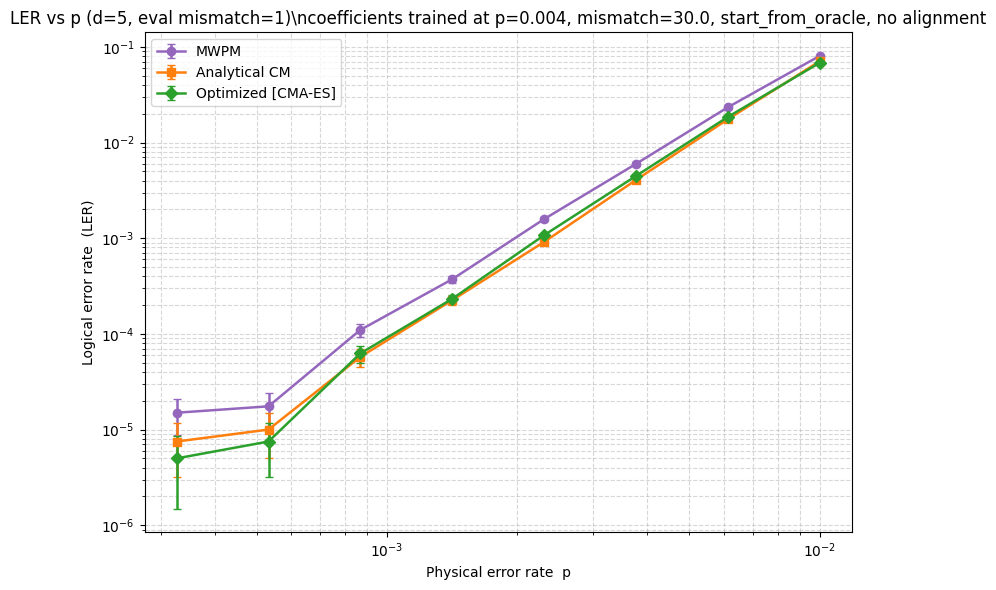

In [ ]:
# ===== Evaluate LER vs p (CLEAN, mismatch=1) for the drift-trained coefficients =====
P_SWEEP    = np.logspace(np.log10(2e-4), np.log10(1e-2), 9)
TARGET_ERR = 500            # stop a p once every decoder reaches this many errors ...
MAX_SHOTS  = 10_000_000_000_000        # ... or this many shots (caps the low-p points)
CHUNK      = 100_000

# best drift-trained coefficients (by the pooled drift objective)
drift_thetas = {'Nelder-Mead': theta_nm_d, 'CMA-ES': theta_cma_d, 'Bayesian opt': theta_bo_d}
best_name = min(drift_thetas, key=lambda k: drift_objective(drift_thetas[k]))
theta_best = drift_thetas[best_name]
print(f"Best drift-trained: {best_name} = {np.round(theta_best, 3)}\n")
print("Evaluating on CLEAN circuits (mismatch=1). Low-p points are shot-limited -> larger bars.\n")

decoders = {'MWPM': ZERO, 'Analytical CM': CM_ANALYTIC, f'Optimized [{best_name}]': theta_best}
sweep = {n: {'p': [], 'ler': [], 'se': []} for n in decoders}

for pv in P_SWEEP:
    tot = {n: 0 for n in decoders}; shots = 0; ci = 0
    while shots < MAX_SHOTS:
        pc = ParametricCM(pv, CHUNK, seed=9000 + ci, mismatch=1.0)   # clean eval circuits
        for n, th in decoders.items():
            tot[n] += pc.mwpm_errs if n == 'MWPM' else pc.errors(th)
        shots += pc.n; ci += 1
        if min(tot.values()) >= TARGET_ERR:
            break
    for n in decoders:
        ler = tot[n] / shots
        sweep[n]['p'].append(pv); sweep[n]['ler'].append(ler); sweep[n]['se'].append(ler_se(ler, shots))
    print(f"p={pv:.2e}  shots={shots:>8,}  | "
          + ' | '.join(f"{n}: {tot[n]:>5d} err  LER {tot[n]/shots:.2e}" for n in decoders))

# ---- plot ----
plt.figure(figsize=(8, 6))
styles = {'MWPM': ('#9467bd', 'o'), 'Analytical CM': ('#ff7f0e', 's'),
          f'Optimized [{best_name}]': ('#2ca02c', 'D')}
for n in decoders:
    p_arr = np.array(sweep[n]['p']); ler = np.array(sweep[n]['ler'], float); se = np.array(sweep[n]['se'])
    c, m = styles[n]
    plt.errorbar(p_arr, np.where(ler > 0, ler, np.nan), yerr=se, marker=m, color=c,
                 capsize=3, linewidth=1.8, markersize=6, label=n)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Physical error rate  p'); plt.ylabel('Logical error rate  (LER)')
plt.title(f'LER vs p (d={DISTANCE}, eval mismatch=1)\\n'
          f'coefficients trained at p={P_TRAIN}, mismatch={MISMATCH_TRAIN}, start_from_oracle, no alignment')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(); plt.tight_layout(); plt.show()

## Same drift protocol, but with `bias = 0` (3-coefficient CM)

Repeat the drift training + clean LER-vs-p exactly as above, but constrain the linear-CM rule to
**`bias = 0`** — matching the analytical CM form. Each optimiser now searches only the **3
coefficients** `(c_joint, c_self, c_nbr)`:

$$\delta w_\mu = \sum_{\nu} s_\nu\,(c_{\text{joint}}\,w_{\mu\nu} + c_{\text{self}}\,w_\mu + c_{\text{nbr}}\,w_\nu)$$

This reuses the same pooled drift objective (`drift_objective`, `drift_objs`) and the same
`P_SWEEP` / sizing knobs defined above, so run those cells first.

In [ ]:
# ===== Train all three methods in the DRIFT setting, with bias FIXED at 0 (3-D search) =====
# Reuses the drift_objs / drift_objective already built above (same realizations, p=4e-3, mismatch=30).
# Each optimiser searches only (c_joint, c_self, c_nbr); bias is appended as 0.

def drift_objective_nobias(theta3):
    """Pooled drift LER for 3 coefficients (c_joint, c_self, c_nbr); bias forced to 0."""
    return drift_objective(np.array([theta3[0], theta3[1], theta3[2], 0.0]))

init_simplex3 = np.vstack([np.zeros(3)] + [0.8 * np.eye(3)[i] for i in range(3)])

# --- Nelder-Mead ---
obj_nm_d0 = Objective(drift_objective_nobias)
minimize(obj_nm_d0, np.zeros(3), method='Nelder-Mead',
         options={'maxiter': NM_MAXITER, 'initial_simplex': init_simplex3, 'xatol': 1e-2, 'fatol': 1e-5})
theta3_nm_d0, ler_nm_d0 = obj_nm_d0.best()
theta_nm_d0 = np.array([*theta3_nm_d0, 0.0])
print(f"Nelder-Mead : {np.round(theta_nm_d0, 3)}  LER={ler_nm_d0:.3e}  ({len(obj_nm_d0.history)} evals)")

# --- CMA-ES ---
obj_cma_d0 = Objective(drift_objective_nobias)
es = cma.CMAEvolutionStrategy(np.zeros(3), 0.5,
     {'bounds': [[SEARCH_BOX[0]] * 3, [SEARCH_BOX[1]] * 3],
      'maxfevals': CMA_MAXFEVALS, 'seed': 1, 'verbose': -9})
es.optimize(obj_cma_d0)
theta3_cma_d0, ler_cma_d0 = obj_cma_d0.best()
theta_cma_d0 = np.array([*theta3_cma_d0, 0.0])
print(f"CMA-ES      : {np.round(theta_cma_d0, 3)}  LER={ler_cma_d0:.3e}  ({len(obj_cma_d0.history)} evals)")

# --- Bayesian opt ---
obj_bo_d0 = Objective(drift_objective_nobias)
gp_minimize(lambda x: obj_bo_d0(x), [SEARCH_BOX] * 3, n_calls=BO_NCALLS, n_initial_points=25,
            acq_func='EI', noise=1e-6, random_state=0)
theta3_bo_d0, ler_bo_d0 = obj_bo_d0.best()
theta_bo_d0 = np.array([*theta3_bo_d0, 0.0])
print(f"Bayesian opt: {np.round(theta_bo_d0, 3)}  LER={ler_bo_d0:.3e}  ({len(obj_bo_d0.history)} evals)")

In [ ]:
# ===== Evaluate LER vs p (CLEAN, mismatch=1) for the bias=0 drift-trained coefficients =====
# Same sweep as above; the only difference is the trained coefficients have bias fixed at 0.
drift_thetas0 = {'Nelder-Mead': theta_nm_d0, 'CMA-ES': theta_cma_d0, 'Bayesian opt': theta_bo_d0}
best_name0 = min(drift_thetas0, key=lambda k: drift_objective(drift_thetas0[k]))
theta_best0 = drift_thetas0[best_name0]
print(f"Best drift-trained (bias=0): {best_name0} = {np.round(theta_best0, 3)}\n")
print("Evaluating on CLEAN circuits (mismatch=1). Low-p points are shot-limited -> larger bars.\n")

decoders0 = {'MWPM': ZERO, 'Analytical CM': CM_ANALYTIC, f'Optimized bias=0 [{best_name0}]': theta_best0}
sweep0 = {n: {'p': [], 'ler': [], 'se': []} for n in decoders0}

for pv in P_SWEEP:
    tot = {n: 0 for n in decoders0}; shots = 0; ci = 0
    while shots < MAX_SHOTS:
        pc = ParametricCM(pv, CHUNK, seed=9000 + ci, mismatch=1.0)   # clean eval circuits
        for n, th in decoders0.items():
            tot[n] += pc.mwpm_errs if n == 'MWPM' else pc.errors(th)
        shots += pc.n; ci += 1
        if min(tot.values()) >= TARGET_ERR:
            break
    for n in decoders0:
        ler = tot[n] / shots
        sweep0[n]['p'].append(pv); sweep0[n]['ler'].append(ler); sweep0[n]['se'].append(ler_se(ler, shots))
    print(f"p={pv:.2e}  shots={shots:>8,}  | "
          + ' | '.join(f"{n}: {tot[n]:>5d} err  LER {tot[n]/shots:.2e}" for n in decoders0))

# ---- plot ----
plt.figure(figsize=(8, 6))
styles0 = {'MWPM': ('#9467bd', 'o'), 'Analytical CM': ('#ff7f0e', 's'),
           f'Optimized bias=0 [{best_name0}]': ('#2ca02c', 'D')}
for n in decoders0:
    p_arr = np.array(sweep0[n]['p']); ler = np.array(sweep0[n]['ler'], float); se = np.array(sweep0[n]['se'])
    c, m = styles0[n]
    plt.errorbar(p_arr, np.where(ler > 0, ler, np.nan), yerr=se, marker=m, color=c,
                 capsize=3, linewidth=1.8, markersize=6, label=n)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Physical error rate  p'); plt.ylabel('Logical error rate  (LER)')
plt.title(f'LER vs p (d={DISTANCE}, eval mismatch=1, bias=0)\\n'
          f'coefficients trained at p={P_TRAIN}, mismatch={MISMATCH_TRAIN}, start_from_oracle, no alignment')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(); plt.tight_layout(); plt.show()